# **Pneumonia Detection**

## **Importing Libraries**

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

2026-06-12 10:56:31.445029: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781261791.671878      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781261791.738224      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781261792.287656      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781261792.287706      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781261792.287709      23 computation_placer.cc:177] computation placer alr

In [2]:
import random
random.seed(0)
import numpy as np
np.random.seed(0)
import tensorflow as tf
tf.random.set_seed(0)

## **Data Collection**

In [3]:
#dataset paths
train_df ="/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train"
test_df="/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test"
val_df = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val"

#verify dataset structure
print("Train classes:",os.listdir(train_df))
print("Test classes:",os.listdir(test_df))
print("Validation classes:",os.listdir(val_df))

Train classes: ['PNEUMONIA', 'NORMAL']
Test classes: ['PNEUMONIA', 'NORMAL']
Validation classes: ['PNEUMONIA', 'NORMAL']


## **EDA**

### **Dataframe Creation** 

In [4]:
path ='/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'
image_path_dict = {}  # Create image path dictionary

for split in ['train', 'test', 'val']:
    split_path = os.path.join(path, split)

    for root, dirs, files in os.walk(split_path):
        for f in files:
            if f.lower().endswith('.jpeg'):
                full_path = os.path.join(root, f)
                image_path_dict[f] = full_path

print("Total images:",len(image_path_dict))

Total images: 5856


In [5]:
pneu_df = pd.DataFrame(list(image_path_dict.items()),columns=['image_name', 'image_path'])

pneu_df.head()
pneu_df.shape


(5856, 2)

In [6]:
pneu_df['image_path'].iloc[0]

'/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/person1180_virus_2010.jpeg'

In [7]:
print("Rows:", len(pneu_df))
print("Unique paths:", pneu_df['image_path'].nunique())
print("Duplicate paths:", pneu_df['image_path'].duplicated().sum())

Rows: 5856
Unique paths: 5856
Duplicate paths: 0


In [8]:
print(pneu_df.columns)

Index(['image_name', 'image_path'], dtype='object')


In [9]:
pneu_df

,image_name,image_path
0,person1180_virus_2010.jpeg,/kaggle/input/datasets/paultimothymooney/chest...
1,person1230_virus_2081.jpeg,/kaggle/input/datasets/paultimothymooney/chest...
2,person1513_virus_2632.jpeg,/kaggle/input/datasets/paultimothymooney/chest...
3,person124_virus_238.jpeg,/kaggle/input/datasets/paultimothymooney/chest...
4,person746_virus_1369.jpeg,/kaggle/input/datasets/paultimothymooney/chest...
...,...,...
5851,NORMAL2-IM-1427-0001.jpeg,/kaggle/input/datasets/paultimothymooney/chest...
5852,NORMAL2-IM-1430-0001.jpeg,/kaggle/input/datasets/paultimothymooney/chest...
5853,NORMAL2-IM-1436-0001.jpeg,/kaggle/input/datasets/paultimothymooney/chest...
5854,NORMAL2-IM-1438-0001.jpeg,/kaggle/input/datasets/paultimothymooney/chest...


In [10]:
pneu_df['label'] = pneu_df['image_path'].apply(lambda x:1 if 'PNEUMONIA' in x else 0)  #labeling

### **Class Distribution**

In [11]:
pneu_df['label'].value_counts()

label
1    4273
0    1583
Name: count, dtype: int64

In [12]:
pneu_df.tail()

,image_name,image_path,label
5851,NORMAL2-IM-1427-0001.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,0
5852,NORMAL2-IM-1430-0001.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,0
5853,NORMAL2-IM-1436-0001.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,0
5854,NORMAL2-IM-1438-0001.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,0
5855,NORMAL2-IM-1437-0001.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,0


### **Plot Distribution**

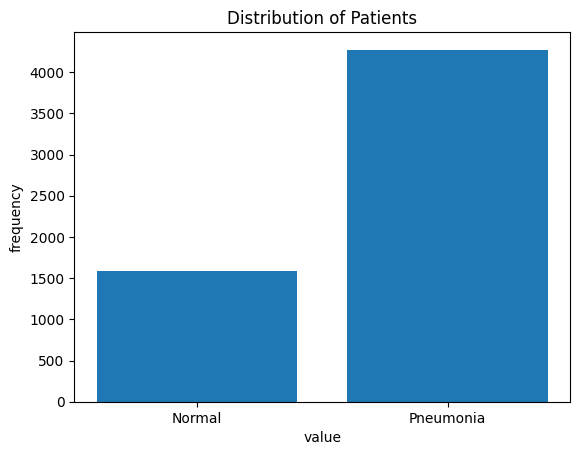

In [13]:
data = pneu_df['label'].value_counts()

plt.bar(data.index, data.values)

plt.xlabel("value")
plt.ylabel("frequency")
plt.title("Distribution of Patients")
plt.xticks([0, 1], ["Normal", "Pneumonia"])
plt.show()

### **Sample Images**  

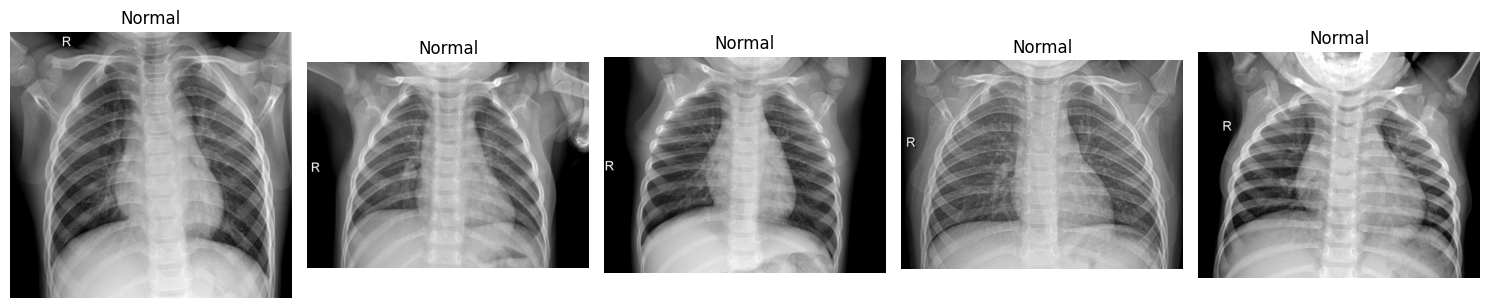

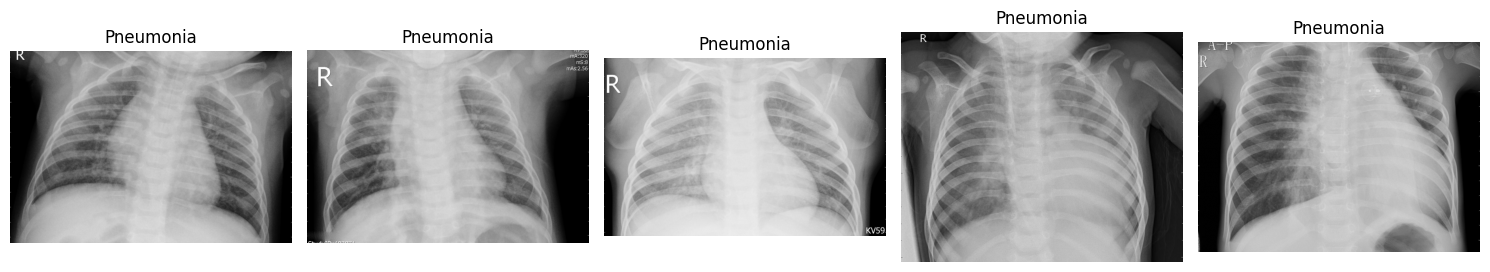

In [14]:
normal_images = pneu_df[pneu_df['label']==0]['image_path'].sample(5, random_state=42)
pneumonia_images = pneu_df[pneu_df['label']==1]['image_path'].sample(5, random_state=42)

plt.figure(figsize=(15, 5))
for i, img_path in enumerate(normal_images):
    img = Image.open(img_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title('Normal')

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 5))
for i, img_path in enumerate(pneumonia_images):
    img = Image.open(img_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title('Pneumonia')

plt.tight_layout()
plt.show()

## **Data Cleaning**

In [15]:
pneu_df.isnull().sum()

image_name    0
image_path    0
label         0
dtype: int64

In [16]:
print("Duplicate Image Names:",pneu_df['image_name'].duplicated().sum())
print("Duplicate Image Path:",pneu_df['image_path'].duplicated().sum())

Duplicate Image Names: 0
Duplicate Image Path: 0


In [17]:
corrupted = []

for path in pneu_df['image_path']:

    try:
        img = Image.open(path)
        img.verify()

    except Exception:
        corrupted.append(path)

print("Corrupted images:", len(corrupted))

Corrupted images: 0


## **Train-Test Split** 

In [18]:
train_df,temp_df = train_test_split(pneu_df,test_size = 0.2,random_state = 42,stratify = pneu_df['label'])

val_df,test_df = train_test_split(temp_df, test_size = 0.5,random_state = 42,stratify = temp_df['label'])

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 4684
Validation: 586
Test: 586


In [19]:
pneu_df

,image_name,image_path,label
0,person1180_virus_2010.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,1
1,person1230_virus_2081.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,1
2,person1513_virus_2632.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,1
3,person124_virus_238.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,1
4,person746_virus_1369.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,1
...,...,...,...
5851,NORMAL2-IM-1427-0001.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,0
5852,NORMAL2-IM-1430-0001.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,0
5853,NORMAL2-IM-1436-0001.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,0
5854,NORMAL2-IM-1438-0001.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,0


## **Image Preprocessing**

In [20]:
import PIL.ImageOps as ImageOps 

def processed_image(image_path):
    img=Image.open(image_path)
    img=img.convert('L')
    img = ImageOps.pad(img,(224, 224),color=0,centering=(0.5, 0.5))
    img=np.array(img)
    img=img/255.0
    img = img[..., np.newaxis]
    return img

In [21]:
sample_img = processed_image(train_df.iloc[0]['image_path'])

print(sample_img.shape)
print(sample_img.min(), sample_img.max())

(224, 224, 1)
0.0 0.8


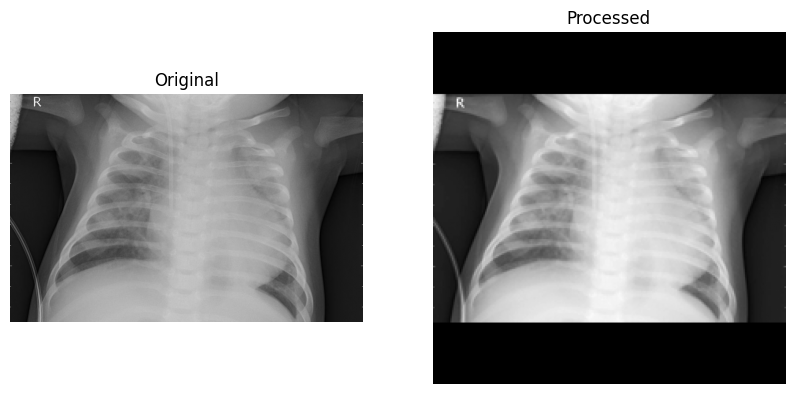

In [22]:
img_path = train_df.iloc[0]['image_path']

original = Image.open(img_path)
processed = processed_image(img_path)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(processed, cmap='gray')
plt.title("Processed")
plt.axis('off')

plt.show()

In [23]:
train_df

,image_name,image_path,label
5552,person124_bacteria_591.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,1
86,person354_bacteria_1634.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,1
3405,person287_bacteria_1355.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,1
2354,person803_virus_1436.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,1
646,person1363_bacteria_3483.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,1
...,...,...,...
2555,person383_bacteria_1747.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,1
4864,IM-0445-0001.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,0
2213,person841_virus_1481.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,1
1131,person677_bacteria_2571.jpeg,/kaggle/input/datasets/paultimothymooney/chest...,1


In [24]:
#training dataset
x_train = np.array([processed_image(path)
                    for path in train_df['image_path']])
y_train = train_df['label'].values

#validation dataset
x_val = np.array([processed_image(path)
                    for path in val_df['image_path']])
y_val = val_df['label'].values

#testing dataset
x_test = np.array([processed_image(path)
                    for path in test_df['image_path']])
y_test = test_df['label'].values


print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

print("x_val:", x_val.shape)
print("y_val:", y_val.shape)

print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train: (4684, 224, 224, 1)
y_train: (4684,)
x_val: (586, 224, 224, 1)
y_val: (586,)
x_test: (586, 224, 224, 1)
y_test: (586,)


In [25]:
print(np.unique(y_train))
print(np.unique(y_val))
print(np.unique(y_test))

[0 1]
[0 1]
[0 1]


In [26]:
sample = processed_image(train_df.iloc[0]['image_path'])
print(sample.shape)

(224, 224, 1)


In [27]:
y_train

array([1, 1, 1, ..., 1, 1, 1], shape=(4684,))

### **Data Augmentation**

In [28]:
train_datagen = ImageDataGenerator(rotation_range = 10,
                                  zoom_range = 0.1,
                                  horizontal_flip = True,
                                  width_shift_range = 0.05,
                                  height_shift_range = 0.05)

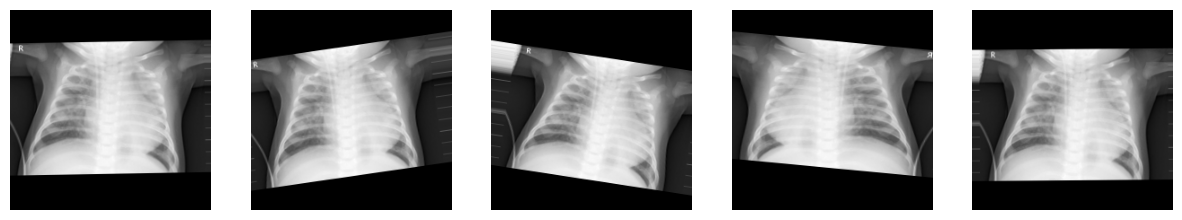

In [29]:
sample = x_train[0].reshape(1,224,224,1)
aug_iter = train_datagen.flow(sample, batch_size=1)
plt.figure(figsize=(15,5))

for i in range(5):
    aug_img = next(aug_iter)[0]
    plt.subplot(1,5,i+1)
    plt.imshow(aug_img.squeeze(), cmap='gray')
    plt.axis('off')

plt.show()

## Data Generators

In [30]:
x_train_rgb = np.repeat(x_train, 3, axis=-1)
x_val_rgb   = np.repeat(x_val, 3, axis=-1)
x_test_rgb  = np.repeat(x_test, 3, axis=-1)

print(x_train_rgb.shape)

(4684, 224, 224, 3)


In [31]:
train_generator = train_datagen.flow(x_train_rgb,y_train,batch_size=32,shuffle=True)
val_generator = ImageDataGenerator().flow(x_val_rgb,y_val,batch_size=32)
test_generator = ImageDataGenerator().flow(x_test_rgb,y_test,batch_size=32,shuffle=False)

In [32]:
print(x_train.shape)
print(x_train_rgb.shape if 'x_train_rgb' in globals() else "Not created")

(4684, 224, 224, 1)
(4684, 224, 224, 3)


## DenseNet Model

In [33]:
base_model = DenseNet121(weights='imagenet',
                         include_top=False,
                         input_shape=(224,224,3))  #loading densenet

base_model.trainable = True    #freezing pretrained layers

print(len(base_model.layers))
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-10:]:
    print(layer.name, layer.trainable)
    
x = base_model.output           #adding classification head
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input,
              outputs=outputs)
model.summary()

I0000 00:00:1781261921.185552      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781261921.191713      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
427
conv5_block15_concat True
conv5_block16_0_bn True
conv5_block16_0_relu True
conv5_block16_1_conv True
conv5_block16_1_bn True
conv5_block16_1_relu True
conv5_block16_2_conv True
conv5_block16_concat True
bn True
relu True


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 904,065 (3.45 MB)

 Non-trainable params: 6,396,096 (24.40 MB)

## Compiling the model

In [34]:
from tensorflow.keras.metrics import Precision,Recall,AUC
from tensorflow.keras.optimizers import Adam

model.compile(optimizer = Adam(1e-4),
             loss = 'binary_crossentropy',
             metrics=['accuracy',Precision(name='precision'),Recall(name='recall'),AUC(name='auc')])

## Handling Class Imbalance

In [35]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(class_weight='balanced',
                              classes=np.unique(train_df['label']),
                              y=train_df['label'])

class_weights = {0:weights[0],
                 1:weights[1]}

In [36]:
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss',
                              patience = 3,
                              restore_best_weights = True)
reduce_lr=ReduceLROnPlateau(monitor='val_loss',
                            factor=0.2,
                            patience=2,
                            min_lr=1e-6,
                            verbose=1)
checkpoint=ModelCheckpoint('best_densenet.keras',
                           monitor='val_loss',
                           save_best_only=True,
                           verbose=1)

history = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=20,
                   class_weight = class_weights,
                   callbacks=[early_stopping,reduce_lr,checkpoint])

Epoch 1/20


I0000 00:00:1781261943.872835      71 service.cc:152] XLA service 0x7ddfbc001f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781261943.872892      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781261943.872896      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781261947.992896      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/147 ━━━━━━━━━━━━━━━━━━━━ 1:35:20 39s/step - accuracy: 0.7188 - auc: 0.7295 - loss: 0.6623 - precision: 0.8182 - recall: 0.7826

I0000 00:00:1781261965.914263      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.8246 - auc: 0.8971 - loss: 0.3814 - precision: 0.9246 - recall: 0.8284
Epoch 1: val_loss improved from None to 0.18871, saving model to best_densenet.keras

Epoch 1: finished saving model to best_densenet.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 131s 626ms/step - accuracy: 0.8836 - auc: 0.9534 - loss: 0.2778 - precision: 0.9533 - recall: 0.8839 - val_accuracy: 0.9300 - val_auc: 0.9838 - val_loss: 0.1887 - val_precision: 0.9849 - val_recall: 0.9180 - learning_rate: 1.0000e-04
Epoch 2/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9317 - auc: 0.9812 - loss: 0.1706 - precision: 0.9750 - recall: 0.9303
Epoch 2: val_loss improved from 0.18871 to 0.16748, saving model to best_densenet.keras

Epoch 2: finished saving model to best_densenet.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 48s 325ms/step - accuracy: 0.9370 - auc: 0.9790 - loss: 0.1797 - precision: 0.9756 - recall: 0.9371 - val_accuracy: 0.9334 - val_auc: 0.9890 - val_loss: 0.167

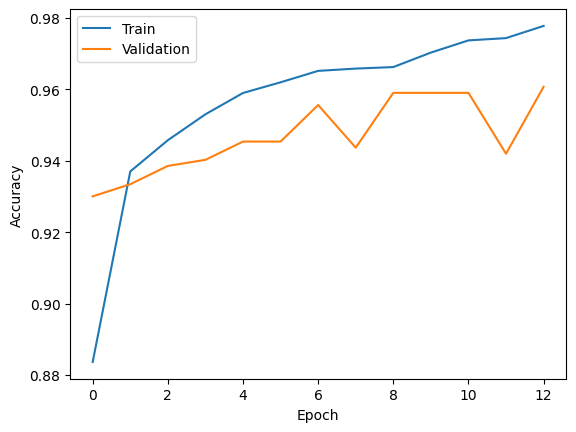

In [37]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

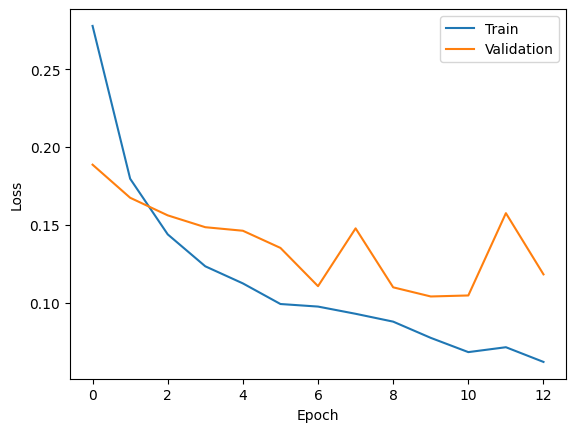

In [38]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig("loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
model.load_weights("best_densenet.keras")

In [40]:
from tensorflow.keras.models import load_model

best_model = load_model("best_densenet.keras")

In [41]:
test_results = best_model.evaluate(test_generator)

19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 503ms/step - accuracy: 0.9778 - auc: 0.9894 - loss: 0.0851 - precision: 0.9905 - recall: 0.9790


In [42]:
from sklearn.metrics import confusion_matrix

y_true = y_test
y_prob = best_model.predict(test_generator)
y_pred = (y_prob > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)

19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 712ms/step


In [43]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_prob = best_model.predict(test_generator)

y_pred = (y_prob > 0.5).astype(int).flatten()

y_true = y_test

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))
print("ROC-AUC:", roc_auc_score(y_true, y_prob))

print("\nClassification Report\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

print("\nConfusion Matrix\n")
print(confusion_matrix(y_true, y_pred))

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step
Precision: 0.9905437352245863
Recall: 0.9789719626168224
F1 Score: 0.9847238542890717
ROC-AUC: 0.9930645924523839

Classification Report

              precision    recall  f1-score   support

      NORMAL       0.94      0.97      0.96       158
   PNEUMONIA       0.99      0.98      0.98       428

    accuracy                           0.98       586
   macro avg       0.97      0.98      0.97       586
weighted avg       0.98      0.98      0.98       586


Confusion Matrix

[[154   4]
 [  9 419]]


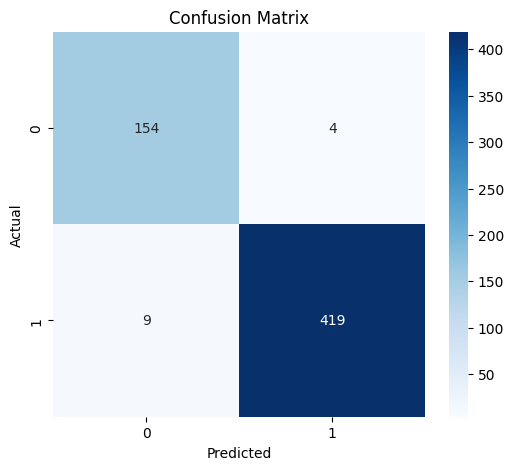

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC =", auc_score)

AUC = 0.9930645924523839


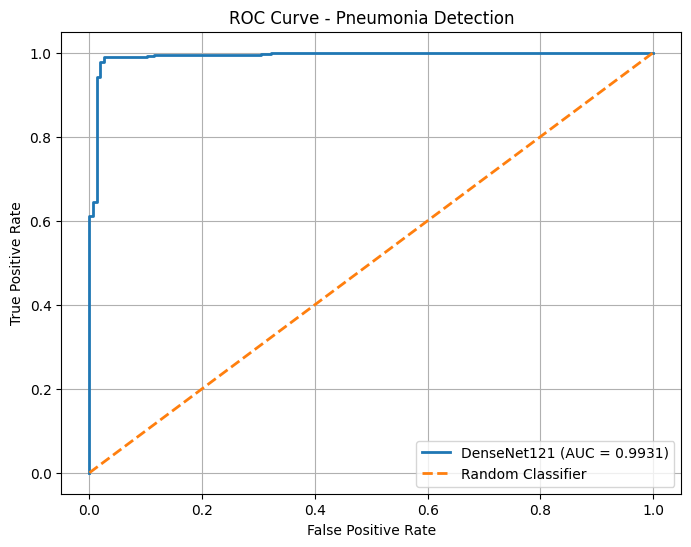

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr,tpr,linewidth=2,label=f'DenseNet121 (AUC = {auc_score:.4f})')

plt.plot([0,1],[0,1],linestyle='--',linewidth=2,label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Pneumonia Detection')
plt.legend(loc='lower right')
plt.grid(True)

plt.savefig("roc_curve_densenet.png", dpi=300, bbox_inches="tight")
plt.show()

## GradCam

True Label: 0


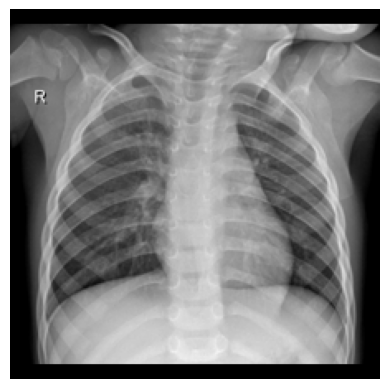

In [47]:
idx = 0

img = x_test_rgb[idx]
label = y_test[idx]

print("True Label:", label)

plt.imshow(img)
plt.axis("off")
plt.show()

In [48]:
img_array = np.expand_dims(img, axis=0)

pred = best_model.predict(img_array)
prob=pred[0][0]

print("Pneumonia Probability:", pred[0][0])
if prob > 0.5:
    print("Prediction: PNEUMONIA")
else:
    print("Prediction: NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Pneumonia Probability: 0.0017256842
Prediction: NORMAL


In [49]:
for i in range(len(x_test_rgb)):
    
    pred = best_model.predict(np.expand_dims(x_test_rgb[i], axis=0),verbose=0)[0][0]

    if pred > 0.99 and y_test[i] == 1:
        idx = i
        break

print("Selected image:", idx)

Selected image: 4


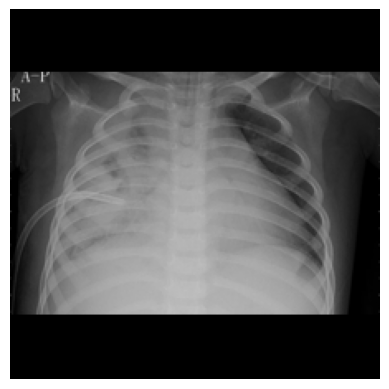

In [50]:
img = x_test_rgb[idx]

plt.imshow(img)
plt.axis("off")
plt.show()

In [51]:
img = x_test_rgb[idx]
img_array = np.expand_dims(img, axis=0)

In [52]:
pred = best_model.predict(img_array)

print("True Label:", y_test[idx])
print("Pneumonia Probability:", pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
True Label: 1
Pneumonia Probability: 0.9999236


In [53]:
for layer in best_model.layers:
    print(layer.name)

best_model.get_layer("conv5_block16_concat")

input_layer
zero_padding2d
conv1_conv
conv1_bn
conv1_relu
zero_padding2d_1
pool1
conv2_block1_0_bn
conv2_block1_0_relu
conv2_block1_1_conv
conv2_block1_1_bn
conv2_block1_1_relu
conv2_block1_2_conv
conv2_block1_concat
conv2_block2_0_bn
conv2_block2_0_relu
conv2_block2_1_conv
conv2_block2_1_bn
conv2_block2_1_relu
conv2_block2_2_conv
conv2_block2_concat
conv2_block3_0_bn
conv2_block3_0_relu
conv2_block3_1_conv
conv2_block3_1_bn
conv2_block3_1_relu
conv2_block3_2_conv
conv2_block3_concat
conv2_block4_0_bn
conv2_block4_0_relu
conv2_block4_1_conv
conv2_block4_1_bn
conv2_block4_1_relu
conv2_block4_2_conv
conv2_block4_concat
conv2_block5_0_bn
conv2_block5_0_relu
conv2_block5_1_conv
conv2_block5_1_bn
conv2_block5_1_relu
conv2_block5_2_conv
conv2_block5_concat
conv2_block6_0_bn
conv2_block6_0_relu
conv2_block6_1_conv
conv2_block6_1_bn
conv2_block6_1_relu
conv2_block6_2_conv
conv2_block6_concat
pool2_bn
pool2_relu
pool2_conv
pool2_pool
conv3_block1_0_bn
conv3_block1_0_relu
conv3_block1_1_conv
con

<Concatenate name=conv5_block16_concat, built=True>

In [54]:
last_conv_layer_name = "conv5_block14_concat"

In [55]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array,model,last_conv_layer_name):
    grad_model = tf.keras.models.Model(model.inputs,[model.get_layer(last_conv_layer_name).output,model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    grads = tape.gradient(loss,conv_outputs)
    pooled_grads = tf.reduce_mean(grads,axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap,0)
    heatmap /= tf.math.reduce_max(heatmap)
    return heatmap.numpy()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


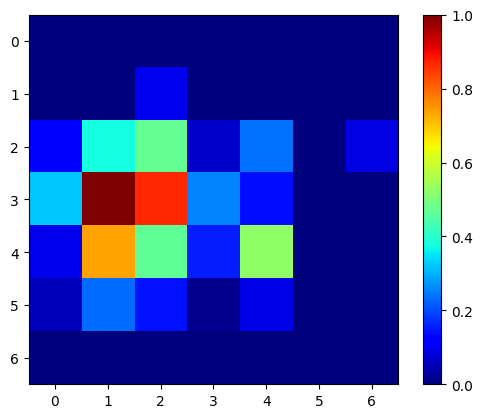

In [56]:
heatmap = make_gradcam_heatmap(img_array,best_model,last_conv_layer_name)
plt.imshow(heatmap,cmap='jet')

plt.colorbar()
plt.show()

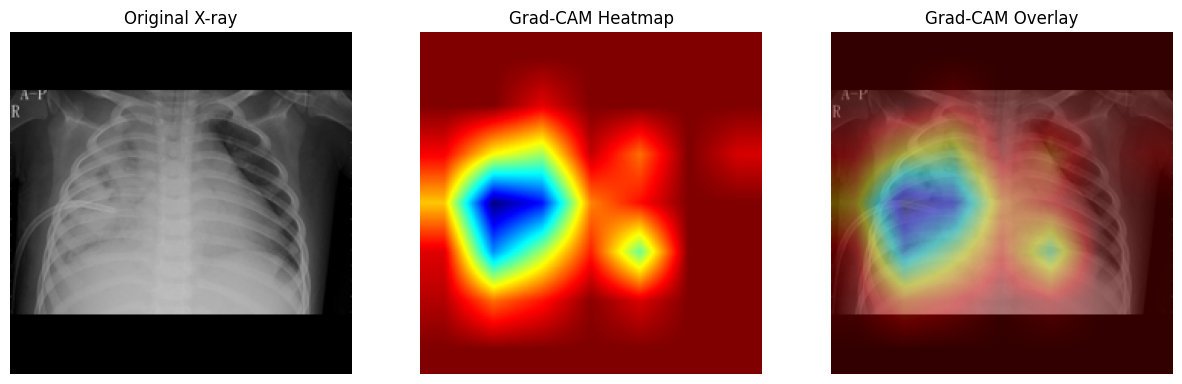

In [57]:
import cv2

heatmap = cv2.resize(heatmap,(224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap,cv2.COLORMAP_JET)
original = (img * 255).astype(np.uint8)
overlay = cv2.addWeighted(original,0.6,heatmap,0.4,0)
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original)
plt.title("Original X-ray")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.show()

In [58]:
best_model.save("best_densenet.keras")